In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("Food_Delivery_Time_Prediction.csv")

In [3]:
df.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,Rainy,Medium,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,Cloudy,Medium,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,Snowy,Medium,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,Cloudy,Low,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,Rainy,High,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Order_ID                    200 non-null    object 
 1   Customer_Location           200 non-null    object 
 2   Restaurant_Location         200 non-null    object 
 3   Distance                    200 non-null    float64
 4   Weather_Conditions          200 non-null    object 
 5   Traffic_Conditions          200 non-null    object 
 6   Delivery_Person_Experience  200 non-null    int64  
 7   Order_Priority              200 non-null    object 
 8   Order_Time                  200 non-null    object 
 9   Vehicle_Type                200 non-null    object 
 10  Restaurant_Rating           200 non-null    float64
 11  Customer_Rating             200 non-null    float64
 12  Delivery_Time               200 non-null    float64
 13  Order_Cost                  200 non

In [5]:
df.isnull()     #from the df.info() it is already clear that no null value is present but still tried to run df.isnull()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
196,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
197,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
198,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [6]:
df["Weather_Conditions"].unique()

array(['Rainy', 'Cloudy', 'Snowy', 'Sunny'], dtype=object)

In [7]:
df["Traffic_Conditions"].unique()

array(['Medium', 'Low', 'High'], dtype=object)

In [8]:
df["Vehicle_Type"].unique()

array(['Car', 'Bike', 'Bicycle'], dtype=object)

In [9]:
# We need to preserve the original columns for feature engineering later, 
# so we concat the one-hot encoded columns but don't drop the originals yet.
categorical_cols = ["Weather_Conditions", "Traffic_Conditions", "Order_Priority", "Order_Time", "Vehicle_Type"]
df_encoded = pd.get_dummies(df[categorical_cols], drop_first=True, dtype=int)
df = pd.concat([df, df_encoded], axis=1)
df.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,...,Weather_Conditions_Sunny,Traffic_Conditions_Low,Traffic_Conditions_Medium,Order_Priority_Low,Order_Priority_Medium,Order_Time_Evening,Order_Time_Morning,Order_Time_Night,Vehicle_Type_Bike,Vehicle_Type_Car
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,Rainy,Medium,4,Medium,Afternoon,Car,...,0,0,1,0,1,0,0,0,0,1
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,Cloudy,Medium,8,Low,Night,Car,...,0,0,1,1,0,0,0,1,0,1
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,Snowy,Medium,9,High,Night,Bike,...,0,0,1,0,0,0,0,1,1,0
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,Cloudy,Low,2,Medium,Evening,Bike,...,0,1,0,0,1,1,0,0,1,0
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,Rainy,High,6,Low,Night,Bike,...,0,0,0,1,0,0,0,1,1,0


In [10]:
# PreviouslyLabelEncoding logic, now merged into Cell 8

In [11]:
df.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,...,Weather_Conditions_Sunny,Traffic_Conditions_Low,Traffic_Conditions_Medium,Order_Priority_Low,Order_Priority_Medium,Order_Time_Evening,Order_Time_Morning,Order_Time_Night,Vehicle_Type_Bike,Vehicle_Type_Car
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,Rainy,Medium,4,Medium,Afternoon,Car,...,0,0,1,0,1,0,0,0,0,1
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,Cloudy,Medium,8,Low,Night,Car,...,0,0,1,1,0,0,0,1,0,1
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,Snowy,Medium,9,High,Night,Bike,...,0,0,1,0,0,0,0,1,1,0
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,Cloudy,Low,2,Medium,Evening,Bike,...,0,1,0,0,1,1,0,0,1,0
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,Rainy,High,6,Low,Night,Bike,...,0,0,0,1,0,0,0,1,1,0


In [12]:
import pandas as pd

df[["Customer_lat", "Customer_lon"]] = df["Customer_Location"].str.strip("()").str.split(",", expand=True)
df[["Restaurant_lat", "Restaurant_lon"]] = df["Restaurant_Location"].str.strip("()").str.split(",", expand=True)

df["Customer_lat"] = df["Customer_lat"].astype(float)
df["Customer_lon"] = df["Customer_lon"].astype(float)
df["Restaurant_lat"] = df["Restaurant_lat"].astype(float)
df["Restaurant_lon"] = df["Restaurant_lon"].astype(float)

In [13]:
import numpy as np
def haversine(lat_1, lon_1, lat2, lon_2):
  R = 6371
  lat_1, lon_1, lat_2, lon_2 = map(np.radians, [lat_1, lon_1, lat2, lon_2])
  dlat = lat_2 - lat_1
  dlon = lon_2 - lon_1
  a = np.sin(dlat/2)**2 + np.cos(lat_1)*np.cos(lat_2)*np.sin(dlon/2)**2
  c = 2*np.arcsin(np.sqrt(a))
  return R*c


In [14]:
df["Distance_calc"] = df.apply(lambda row: haversine(row["Restaurant_lat"],
                                                     row["Restaurant_lon"],
                                                     row["Customer_lat"],
                                                     row["Customer_lon"]), axis=1)

In [15]:
df[["Distance", "Distance_calc"]].head()

,Distance,Distance_calc
0,1.57,775.651198
1,21.32,1042.385597
2,6.95,476.220706
3,13.79,389.912629
4,6.72,806.505886


In [16]:
from sklearn.preprocessing import StandardScaler
# Removed 'Delivery_Time' from numeric_cols to avoid scaling the target variable
numeric_cols = ["Distance_calc", "Delivery_Person_Experience", "Restaurant_Rating", "Customer_Rating", "Order_Cost", "Tip_Amount"]
Scaler = StandardScaler()
df[numeric_cols] = Scaler.fit_transform(df[numeric_cols])

In [17]:
df.tail()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,...,Order_Time_Evening,Order_Time_Morning,Order_Time_Night,Vehicle_Type_Bike,Vehicle_Type_Car,Customer_lat,Customer_lon,Restaurant_lat,Restaurant_lon,Distance_calc
195,ORD0196,"(17.910045, 81.56199)","(18.098924, 87.896124)",23.82,Cloudy,High,1.004325,Medium,Night,Bike,...,0,0,1,1,0,17.910045,81.561990,18.098924,87.896124,0.249303
196,ORD0197,"(21.66459, 82.226635)","(16.892341, 80.554716)",6.09,Snowy,Medium,1.004325,Low,Night,Bicycle,...,0,0,1,0,0,21.664590,82.226635,16.892341,80.554716,-0.164040
197,ORD0198,"(14.575401, 82.55641)","(13.625369, 82.418092)",20.61,Snowy,High,-0.456512,Medium,Afternoon,Bike,...,0,0,0,1,0,14.575401,82.556410,13.625369,82.418092,-1.844339
198,ORD0199,"(12.094497, 82.893369)","(19.135509, 86.659978)",24.06,Rainy,High,1.369535,Low,Night,Car,...,0,0,1,0,1,12.094497,82.893369,19.135509,86.659978,1.031290
199,ORD0200,"(19.360304, 84.132424)","(20.941636, 77.01334)",9.18,Snowy,Low,-1.186930,Low,Morning,Bike,...,0,1,0,1,0,19.360304,84.132424,20.941636,77.013340,0.596548


In [18]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Distance,200.0,1.149805e+01,6.841755,0.520000,6.090000,10.265000,16.497500,24.900000
Delivery_Person_Experience,200.0,4.440892e-18,1.002509,-1.552139,-0.821721,-0.091302,1.004325,1.734744
Restaurant_Rating,200.0,3.463896e-16,1.002509,-1.766103,-0.767902,0.087699,0.800700,1.798901
Customer_Rating,200.0,4.529710e-16,1.002509,-1.562593,-0.843498,0.019416,0.882330,1.889062
Delivery_Time,200.0,7.049495e+01,29.830694,15.230000,46.997500,72.775000,96.650000,119.670000
Order_Cost,200.0,-2.042810e-16,1.002509,-1.688954,-0.901357,-0.019259,0.907603,1.737826
Tip_Amount,200.0,-4.440892e-18,1.002509,-1.549315,-0.854069,0.031185,0.806753,1.813813
Weather_Conditions_Rainy,200.0,2.850000e-01,0.452547,0.000000,0.000000,0.000000,1.000000,1.000000
Weather_Conditions_Snowy,200.0,2.400000e-01,0.428155,0.000000,0.000000,0.000000,0.000000,1.000000
Weather_Conditions_Sunny,200.0,2.650000e-01,0.442441,0.000000,0.000000,0.000000,1.000000,1.000000


In [19]:
for cols in df.select_dtypes(include=['float64', 'int64']).columns:
  print(f"{cols}:-")
  print("Mean:", df[cols].mean())
  print("Mean:", df[cols].mean())
  print("Mode:", df[cols].mode()[0])
  print("Variance:", df[cols].var())
  print("Standard Variance:", df[cols].std())
  print('\n')

Distance:-
Mean: 11.498050000000001
Mean: 11.498050000000001
Mode: 1.32
Variance: 46.80961678140704
Standard Variance: 6.84175538742851


Delivery_Person_Experience:-
Mean: 4.440892098500626e-18
Mean: 4.440892098500626e-18
Mode: 1.0043254236146966
Variance: 1.0050251256281408
Standard Variance: 1.002509414234171


Restaurant_Rating:-
Mean: 3.4638958368304885e-16
Mean: 3.4638958368304885e-16
Mode: 0.08769909132992527
Variance: 1.0050251256281406
Standard Variance: 1.002509414234171


Customer_Rating:-
Mean: 4.529709940470639e-16
Mean: 4.529709940470639e-16
Mode: -1.5625933649946497
Variance: 1.0050251256281408
Standard Variance: 1.002509414234171


Delivery_Time:-
Mean: 70.49494999999999
Mean: 70.49494999999999
Mode: 66.84
Variance: 889.8703226105528
Standard Variance: 29.830694303193024


Order_Cost:-
Mean: -2.042810365310288e-16
Mean: -2.042810365310288e-16
Mode: 1.401255869563944
Variance: 1.005025125628141
Standard Variance: 1.0025094142341713


Tip_Amount:-
Mean: -4.440892098500626

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
# Use numeric_only=True perfectly bypasses any string conversion issues
correlate = df.corr(numeric_only=True)
print(correlate["Delivery_Time"].sort_values(ascending=False))

plt.figure(figsize=(12, 10))
sns.heatmap(correlate, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

ModuleNotFoundError: No module named 'seaborn'

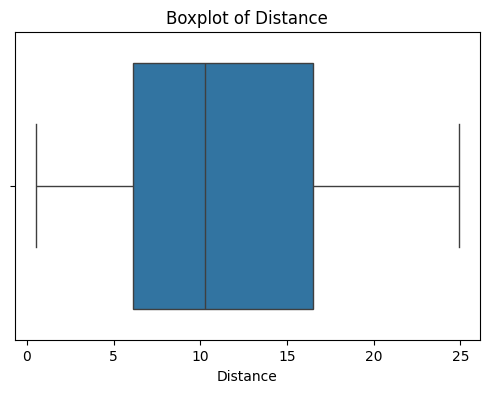

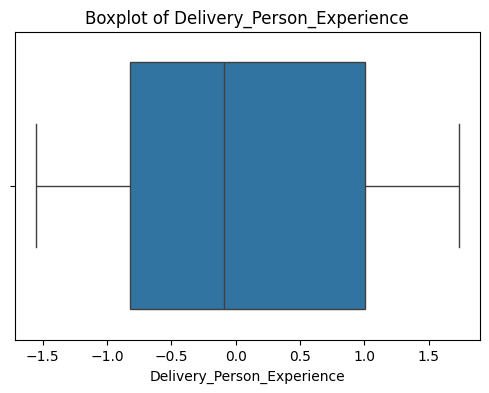

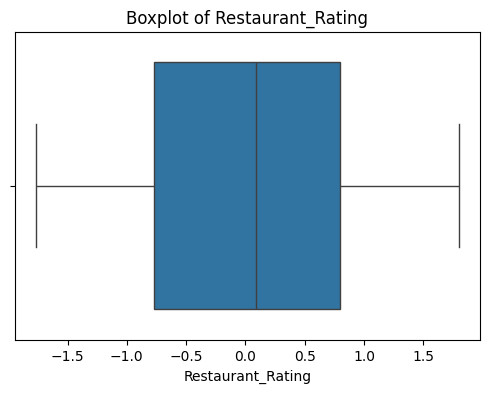

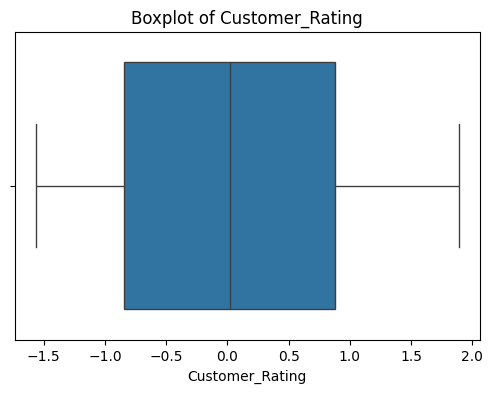

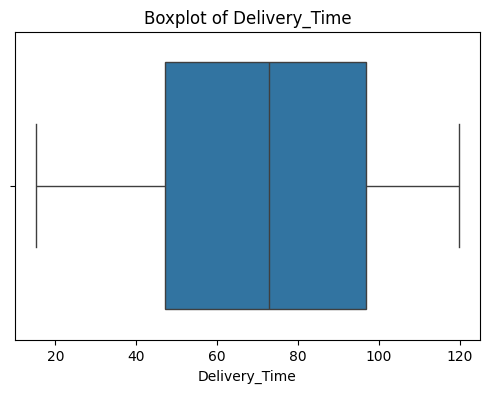

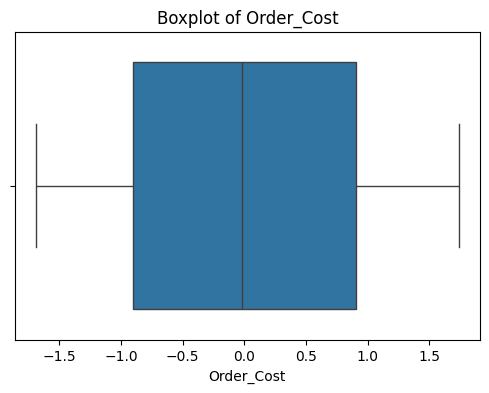

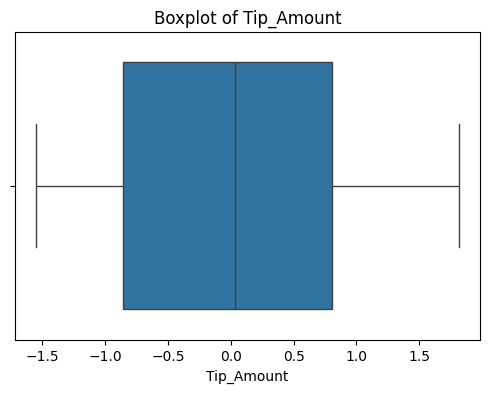

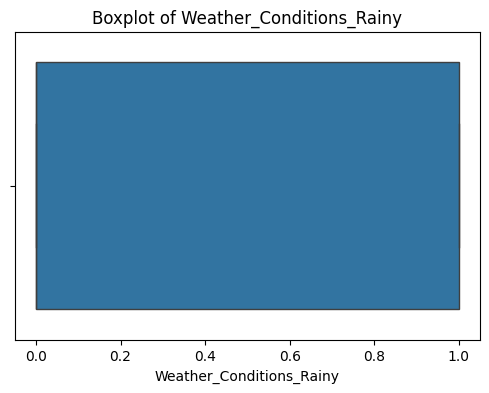

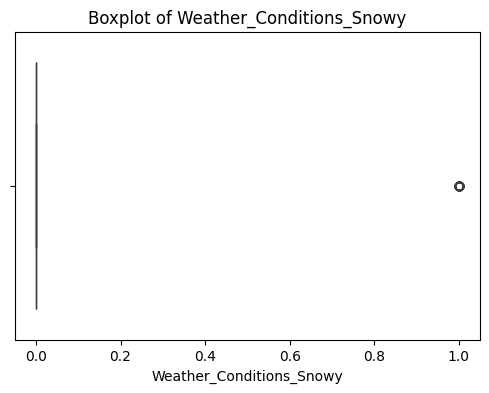

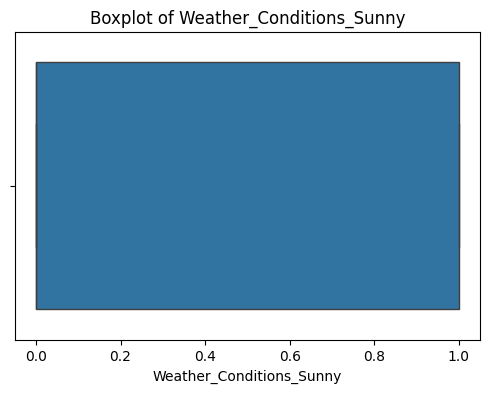

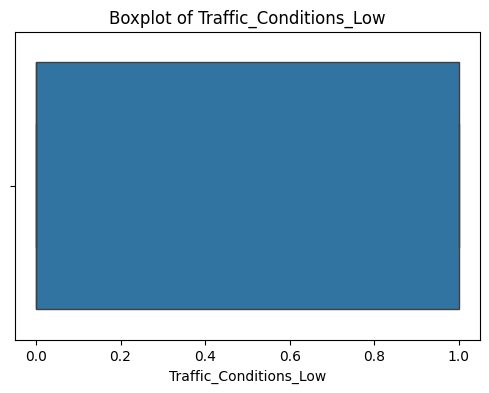

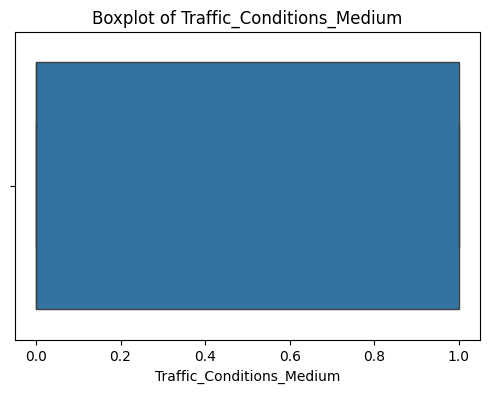

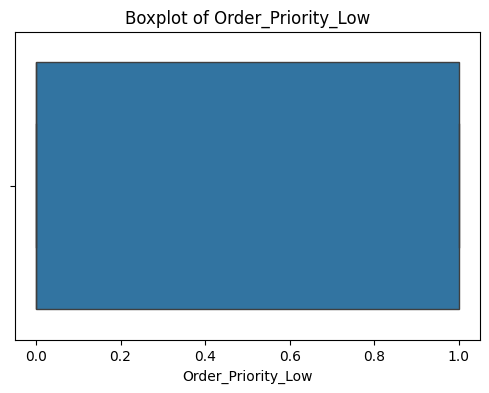

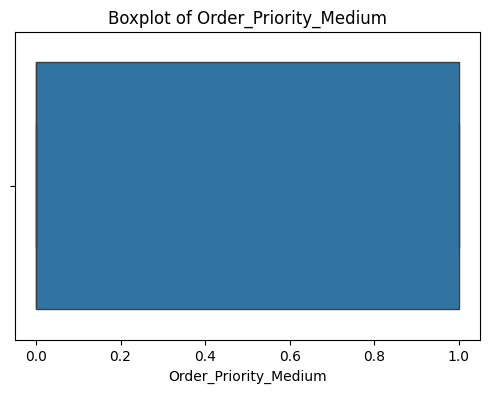

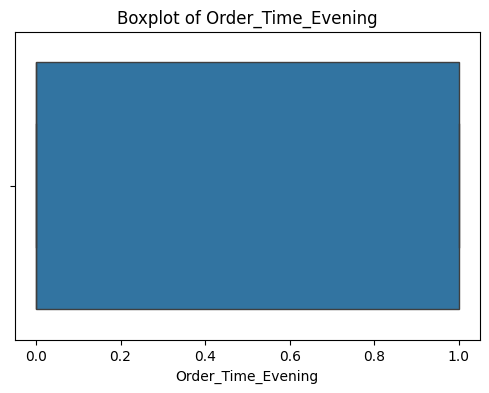

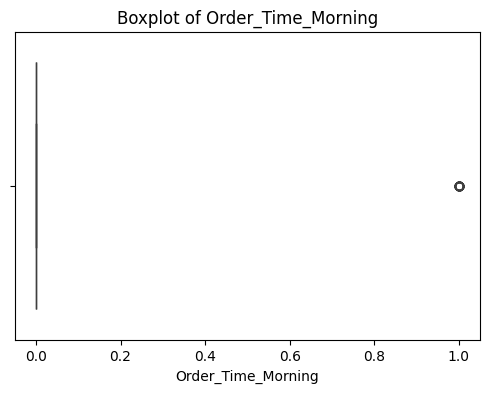

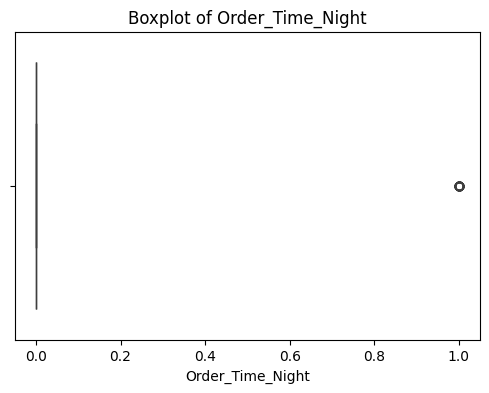

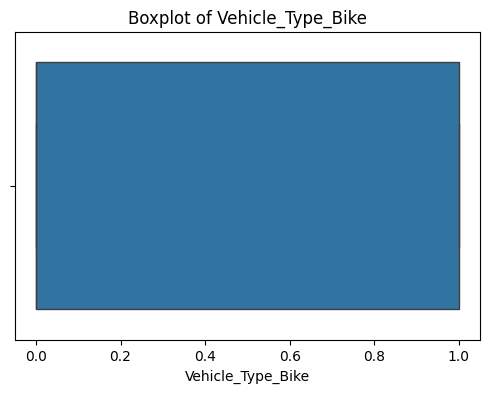

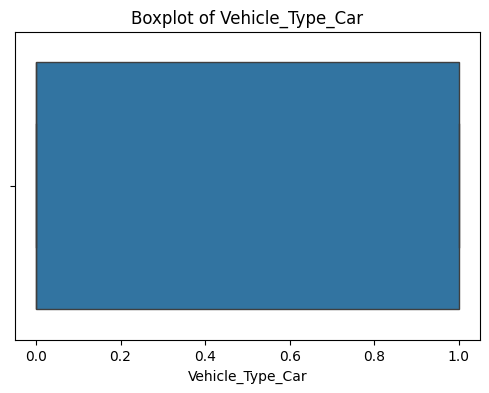

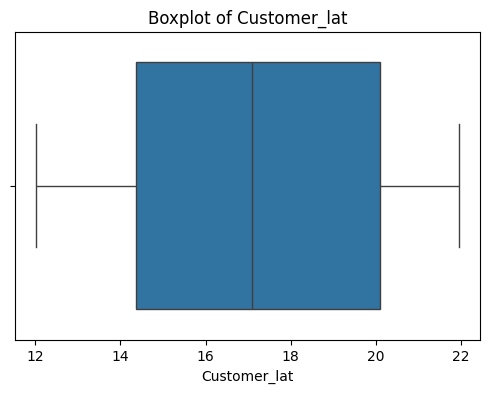

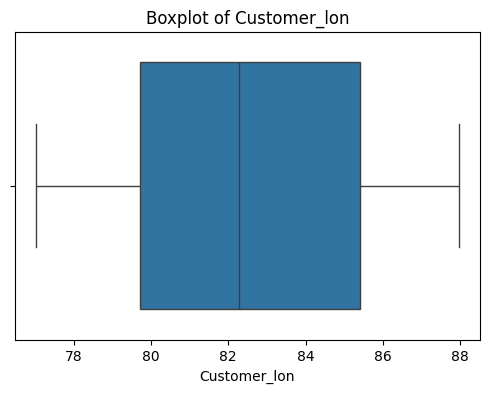

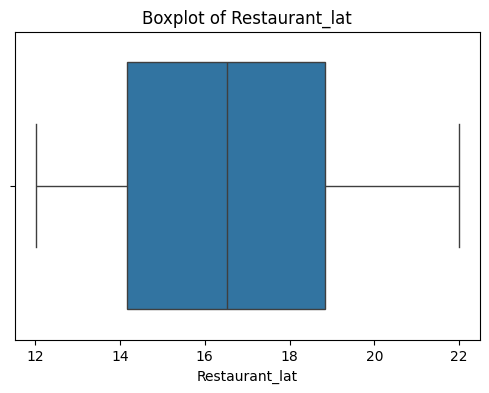

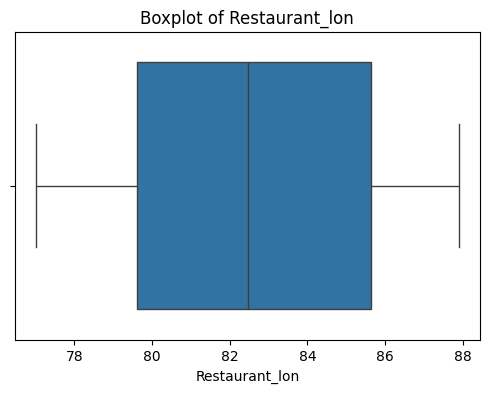

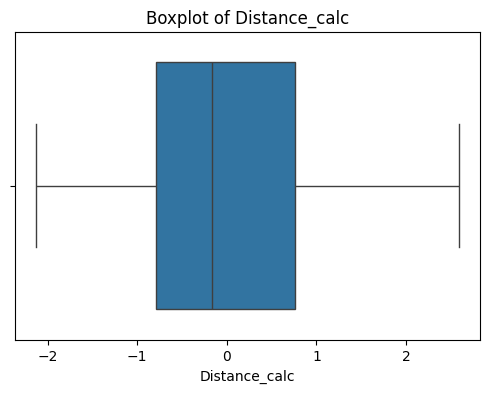

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
numeric_cols = df.select_dtypes(include=['float64','int64']).columns
for col in numeric_cols:
  plt.figure(figsize=(6,4))
  sns.boxplot(x=df[col])
  plt.title(f"Boxplot of {col}")
  plt.show()


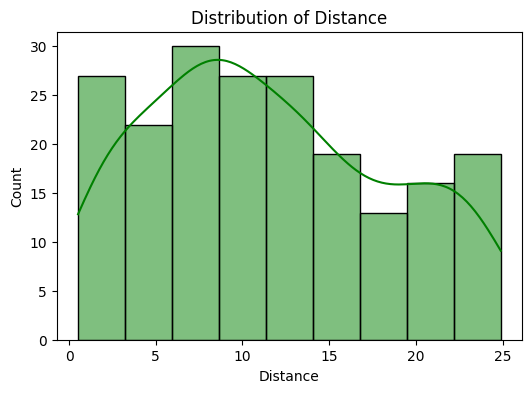

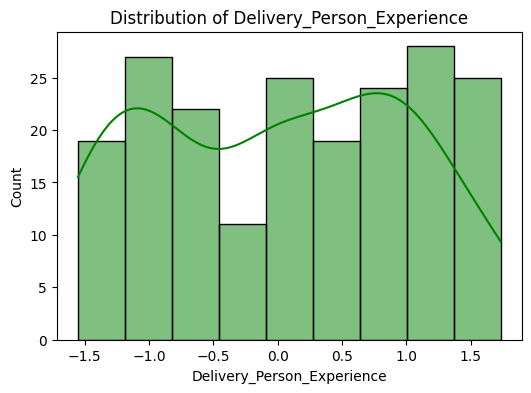

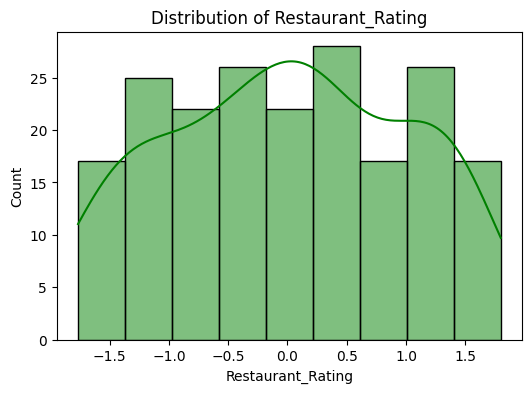

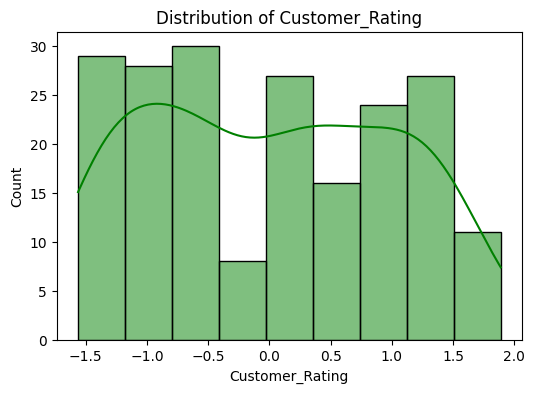

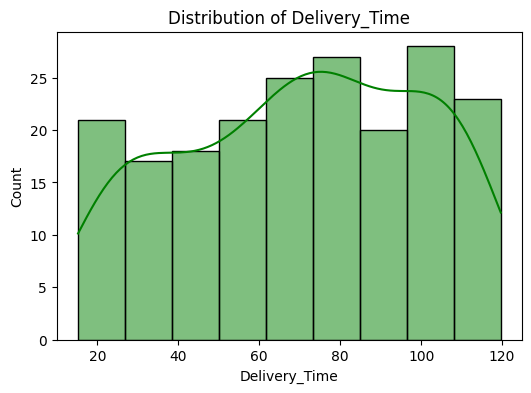

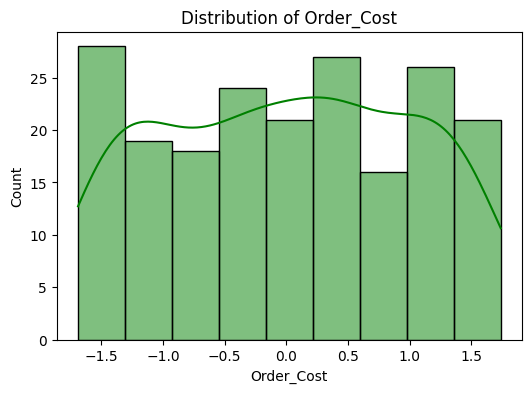

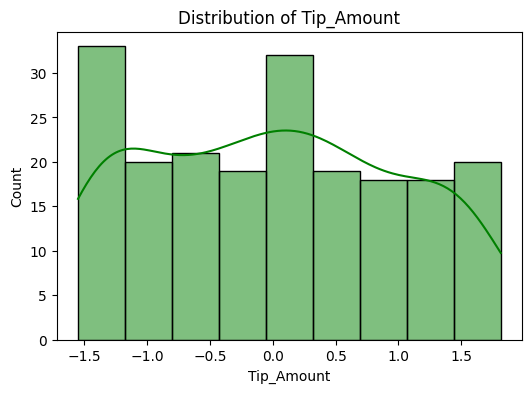

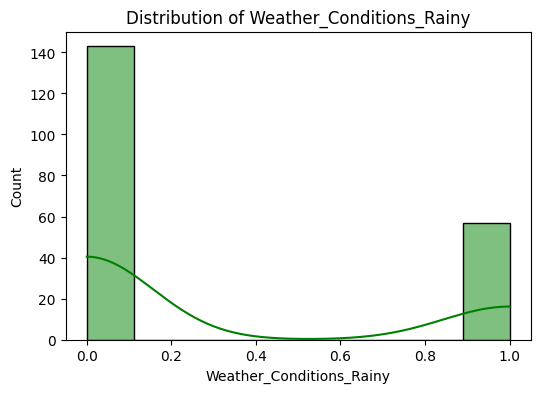

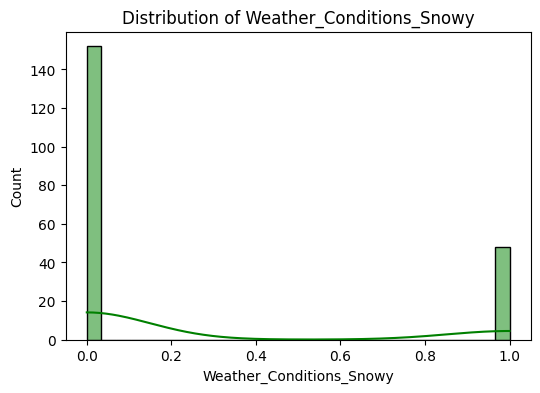

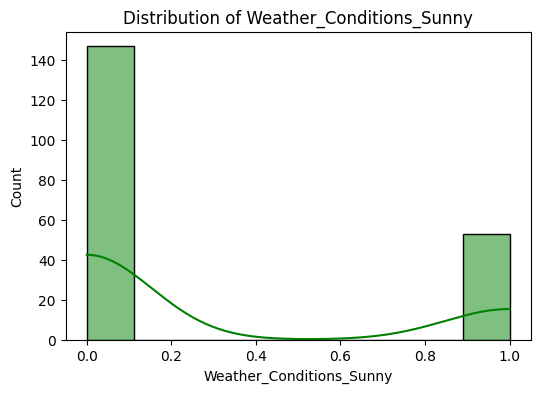

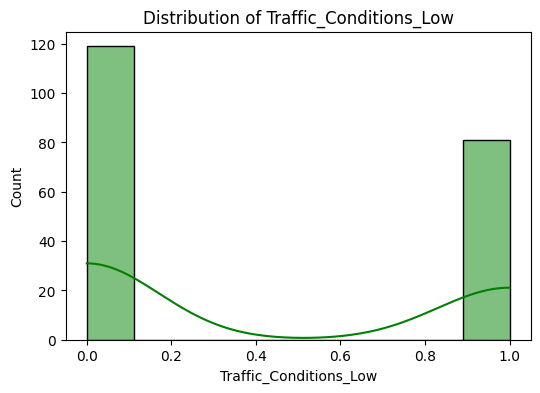

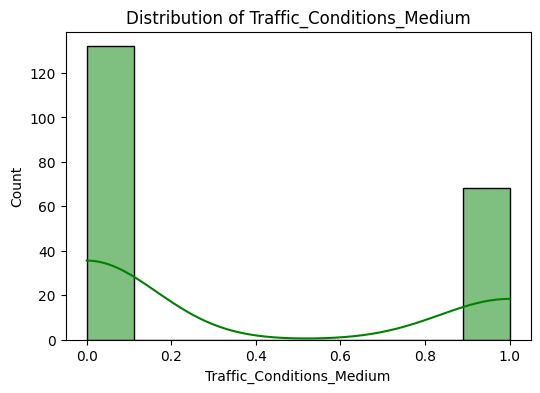

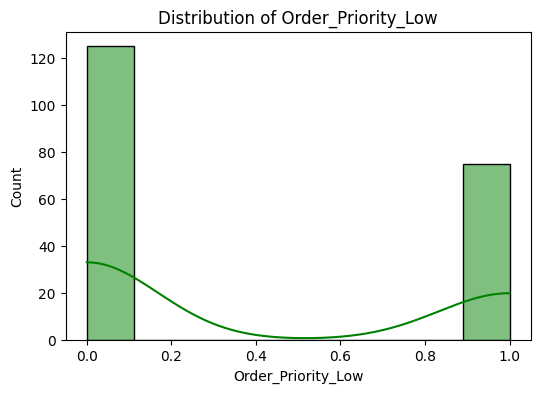

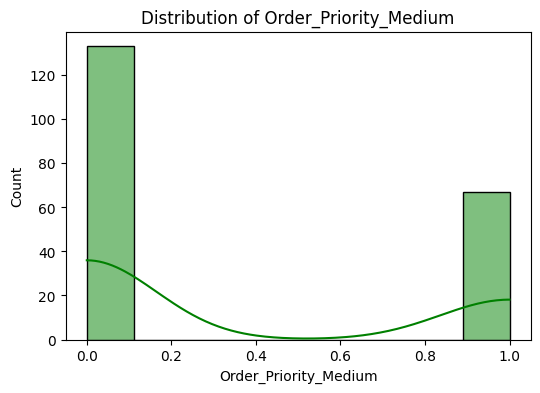

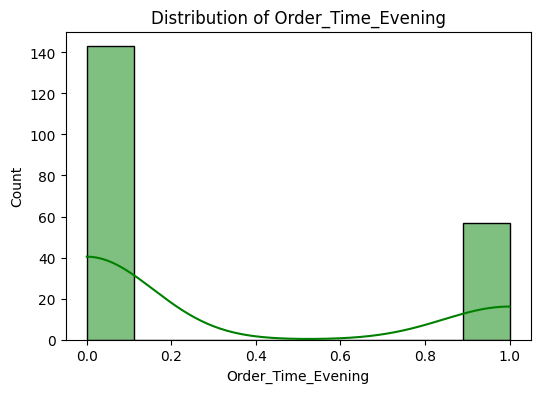

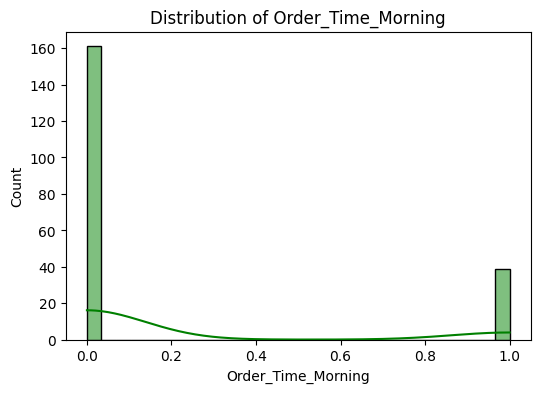

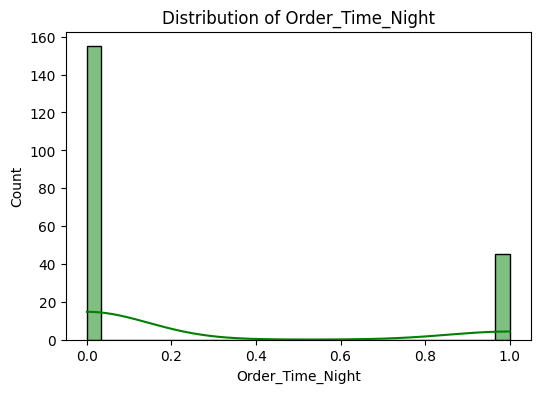

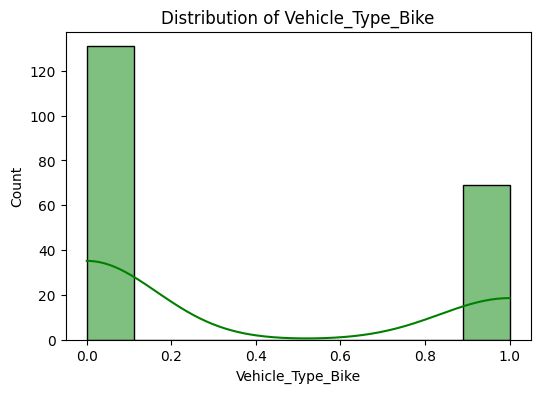

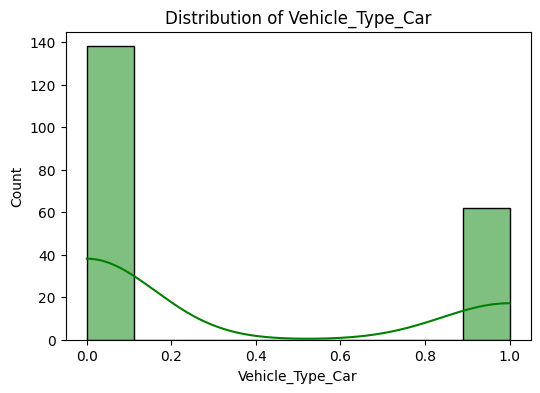

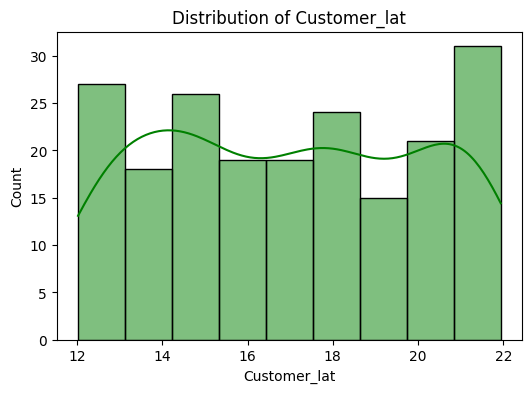

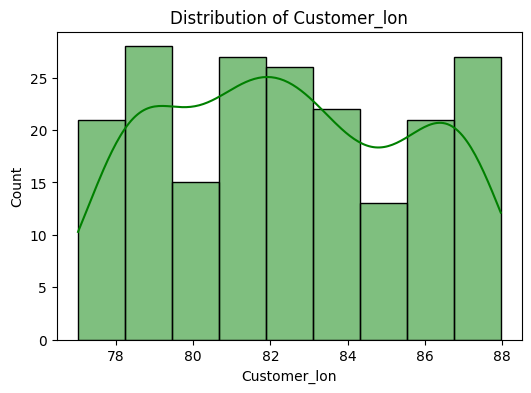

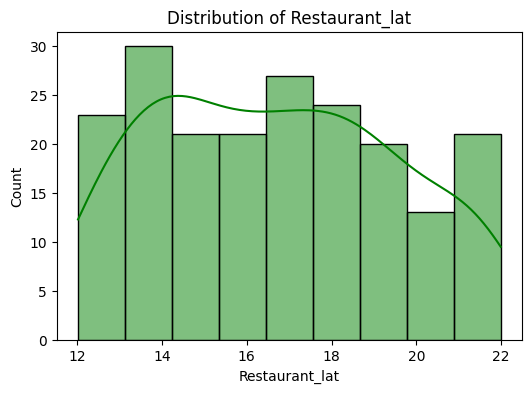

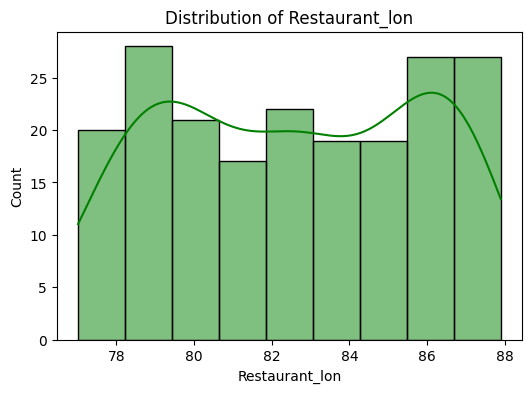

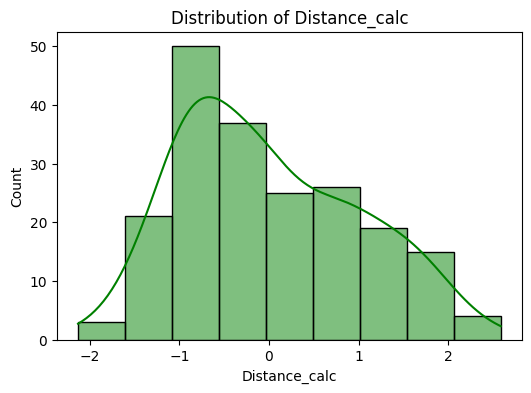

In [ ]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, color='green')
    plt.title(f"Distribution of {col}")
    plt.show()

In [ ]:
# Outlier Treatment using IQR method
# Excluding Delivery_Time since it's the target variable
numeric_cols = ["Distance_calc", "Delivery_Person_Experience", "Restaurant_Rating", "Customer_Rating", "Order_Cost", "Tip_Amount"]
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
print("Outliers treated using IQR capping method.")

Outliers treated using IQR capping method.


In [ ]:
# Outlier Treatment using IQR method
# Excluding Delivery_Time since it's the target variable
numeric_cols = ["Distance_calc", "Delivery_Person_Experience", "Restaurant_Rating", "Customer_Rating", "Order_Cost", "Tip_Amount"]
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
print("Outliers treated using IQR capping method.")

Outliers treated using IQR capping method.


In [ ]:
df["Rush_Hour"] = df["Order_Time"].apply(lambda x: 1 if x in ["Morning","Evening"] else 0)

In [ ]:
def meal_time(period):
    if period == "Afternoon":
        return "Lunch"
    elif period == "Evening":
        return "Dinner"
    elif period == "Morning":
        return "breakfast"
    elif period == "Night":
        return "Late_Dinner"
    else:
        return "Other"

df["Meal_Time"] = df["Order_Time"].apply(meal_time)

In [ ]:
df.head(15).transpose()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
Order_ID,ORD0001,ORD0002,ORD0003,ORD0004,ORD0005,ORD0006,ORD0007,ORD0008,ORD0009,ORD0010,ORD0011,ORD0012,ORD0013,ORD0014,ORD0015
Customer_Location,"(17.030479, 79.743077)","(15.398319, 86.639122)","(15.687342, 83.888808)","(20.415599, 78.046984)","(14.786904, 78.706532)","(15.560205, 80.59125)","(21.397639, 84.89693)","(12.512731, 86.268971)","(18.814724, 86.95472)","(14.364647, 87.968582)","(13.516083, 77.368398)","(21.81819, 81.305941)","(15.800841, 79.0468)","(17.328378, 81.85932)","(12.865312, 81.430712)"
Restaurant_Location,"(12.358515, 85.100083)","(14.174874, 77.025606)","(19.594748, 82.048482)","(16.915906, 78.278698)","(15.206038, 86.203182)","(12.478068, 78.823965)","(15.934011, 86.767357)","(12.019922, 78.4686)","(15.30437, 84.059261)","(13.508338, 84.206901)","(21.043034, 80.024796)","(19.321344, 80.471393)","(19.299898, 77.014496)","(21.881675, 82.349324)","(16.452125, 83.164956)"
Distance,1.57,21.32,6.95,13.79,6.72,10.0,5.15,22.57,13.19,19.56,18.34,3.04,1.34,0.87,10.07
Weather_Conditions,Rainy,Cloudy,Snowy,Cloudy,Rainy,Rainy,Sunny,Snowy,Snowy,Snowy,Rainy,Sunny,Snowy,Cloudy,Cloudy
Traffic_Conditions,Medium,Medium,Medium,Low,High,High,Medium,Medium,Medium,Medium,High,Low,Low,High,Low
Delivery_Person_Experience,-0.456512,1.004325,1.369535,-1.18693,0.273907,1.734744,0.273907,0.639116,1.004325,1.004325,0.639116,0.639116,0.639116,-1.552139,0.273907
Order_Priority,Medium,Low,High,Medium,Low,Medium,High,Low,Low,High,Low,High,High,Medium,Medium
Order_Time,Afternoon,Night,Night,Evening,Night,Evening,Evening,Evening,Night,Afternoon,Afternoon,Afternoon,Morning,Evening,Evening
Vehicle_Type,Car,Car,Bike,Bike,Bike,Bicycle,Car,Bicycle,Bicycle,Bicycle,Car,Bike,Bicycle,Bike,Car


### Feature Selection Justification
We choose features logically correlating with delivery time:
- **Distance_calc**: The recalculated distance between the restaurant and custom (which is more accurate than raw Distance) is fundamentally tied to how long a trip takes.
- **Traffic_Conditions**: Heavier traffic equates to longer delays. We use the one-hot encoded variables for this.
- **Order_Priority**: Orders with higher priority might be dispatched faster. We use the one-hot encoded variables for this.

### Feature Selection Justification
We choose features logically correlating with delivery time:
- **Distance_calc**: The recalculated distance between the restaurant and custom (which is more accurate than raw Distance) is fundamentally tied to how long a trip takes.
- **Traffic_Conditions**: Heavier traffic equates to longer delays. We use the one-hot encoded variables for this.
- **Order_Priority**: Orders with higher priority might be dispatched faster. We use the one-hot encoded variables for this.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Using recalculated Distance_calc and one-hot encoded categorical variables
# For Traffic: 'Traffic_Conditions_Low', 'Traffic_Conditions_Medium'
# For Priority: 'Order_Priority_Low', 'Order_Priority_Medium'
selected_features = ["Distance_calc", "Traffic_Conditions_Low", "Traffic_Conditions_Medium", "Order_Priority_Low", "Order_Priority_Medium"]

# Just in case some columns are differently named based on dataset unique values, we smartly pick them:
actual_features = selected_features

X = df[actual_features]
y = df["Delivery_Time"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred_lr)
mae = mean_absolute_error(y_test, y_pred_lr)
r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance:")
print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("R2 Score (R²):", r2)
print("\nInterpretation: The R2 score shows how much variance in Delivery Time is explained by our features. Lower MAE and MSE indicate better distance predictions.")

Linear Regression Performance:
Mean Squared Error (MSE): 859.2748519808187
Mean Absolute Error (MAE): 24.713972917397093
R2 Score (R²): 0.07094494659170547

Interpretation: The R2 score shows how much variance in Delivery Time is explained by our features. Lower MAE and MSE indicate better distance predictions.


In [ ]:
threshold = df["Delivery_Time"].quantile(0.75)
df["Delivery_Status"] = df["Delivery_Time"].apply(lambda x: 1 if x <= threshold else 0)

In [ ]:
# Logistic Regression Features
# We will use Traffic Conditions, Weather Conditions, Experience, and Order Time
logreg_features = [col for col in df.columns if any(feat in col for feat in ["Traffic_Conditions_", "Weather_Conditions_", "Delivery_Person_Experience", "Order_Time_"])]

X_class = df[logreg_features]
y_class = df["Delivery_Status"]

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_class, y_class, test_size=0.2, random_state=42)

model_logreg = LogisticRegression(max_iter=1000)
model_logreg.fit(X_train_c, y_train_c)
y_pred_logreg = model_logreg.predict(X_test_c)
y_prob_logreg = model_logreg.predict_proba(X_test_c)[:, 1]

print("Logistic Regression Performance:")
print("Accuracy:", accuracy_score(y_test_c, y_pred_logreg))
print("Precision:", precision_score(y_test_c, y_pred_logreg, pos_label=1))
print("Recall:", recall_score(y_test_c, y_pred_logreg, pos_label=1))
print("F1-score:", f1_score(y_test_c, y_pred_logreg, pos_label=1))
print("\nInterpretation: Precision and Recall tell us how well the model predicts 'Fast' deliveries without misclassifying delayed ones.")


Logistic Regression Performance:
Accuracy: 0.8
Precision: 0.8
Recall: 1.0
F1-score: 0.8888888888888888

Interpretation: Precision and Recall tell us how well the model predicts 'Fast' deliveries without misclassifying delayed ones.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_c, y_pred_logreg)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Delayed", "Fast"], yticklabels=["Delayed", "Fast"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

ModuleNotFoundError: No module named 'seaborn'

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test_c, y_prob_logreg)
auc_score = roc_auc_score(y_test_c, y_prob_logreg)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'Logistic Regression (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

NameError: name 'plt' is not defined

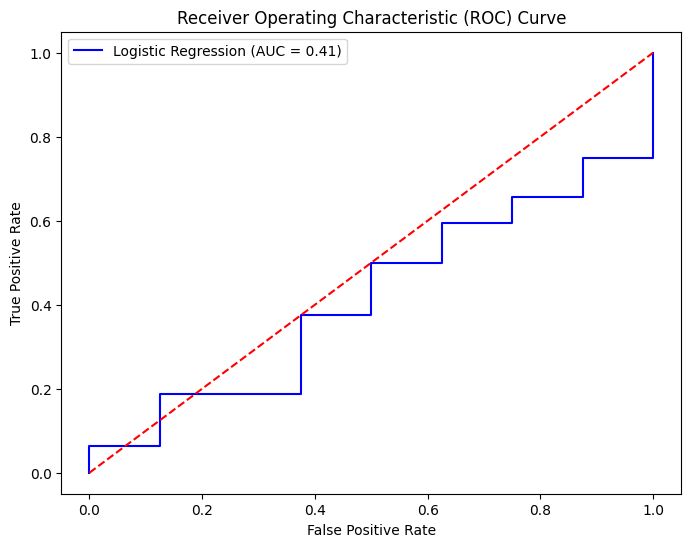

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test_c, y_prob_logreg)
auc_score = roc_auc_score(y_test_c, y_prob_logreg)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'Logistic Regression (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

# Summary:-

## Dataset Description:-
*   The dataset contains the details of the food deliveries, customer experience, Order time, order priority, etc.
*   Target Variables: Delivery_status & Delivery_time

## Preprocessing Steps:-
*   Data Cleaning: No missing or inconsistent values.
*   Feature Engineering: New features like distance recalculated via haversine.
*   Encoding: One-hot encoding implemented to avoid ordinal bias for categorical variables.
*   Standardization: Applied to predictor features (excluding the target Delivery_Time itself) to align scales.
*   Outlier Treatment: Implemented clipping using IQR techniques on numeric fields mapping.

## Model Evaluation

### Linear Regression vs Logistic Regression Comparison
We used two distinct approaches for two different objectives:
1. **Linear Regression**: Used to predict the exact continuous magnitude of delivery time (`Delivery_Time`). This reveals *how long* a delivery will take.
2. **Logistic Regression**: Used to classify whether a delivery will be 'Fast' or 'Delayed' (`Delivery_Status`). This reveals *whether* service level agreements are met.

Linear Regression depends heavily on physical constraints (e.g. Distance_calc), whereas Logistic Regression handles binary confidence thresholds well, making them complementary rather than competing models.

*   Visualization
    * Correlation Heatmap
    * Confusion Matrix Heatmap
    * Histogram & Boxplot
    * ROC curve for Logistic Regression

# Actionable Insights

### Optimizing Delivery Routes :-
*   Can perform Route Optimatization to minimize the cost and time of delivery person and the customer
*   Can use Linear Regression to identify the long-distance deliveries.

### Adjusting staffing during high-traffic periods :-

*   Increase staffing and shift scheduling during rush hours.

### Providing better training to delivery staff

*   Order_Time feature highlights peak delay periods (e.g., evenings).
*   Offer incentives for customers to order earlier, or allocate more drivers at peak times.
*   Offer bonuses to the delivery staffs for performing most or the highest number of delivery for a specific period of time (e.g., Rush Hours , Festival Offers).



